In [1]:
import os
import numpy as np
import torch

from sensorium.utility import get_data, set_random_seed

from utils import load_model_from_config, get_knn_curve, get_ari_curve
import matplotlib.pyplot as plt

random_seed = 42
set_random_seed(random_seed, deterministic=False)

device = 'cuda:7'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"
# as filenames, we'll select all 7 datasets

filenames = [] 
for file in [
    'static23343-5-17-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static23964-4-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
    'static23656-14-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static21067-10-18-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static22846-10-16-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static27204-5-13-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
]:
    filenames.append(os.path.join(basepath, file))

dataset_fn = "sensorium.datasets.static_loaders"

dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "exclude_eye_position_paths": [
        '/srv/user/polina/sensorium/sensorium/notebooks/data/static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6'
    ],
    "batch_size": 128,
    "scale": 0.25,
}
dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

In [27]:
paths = {}
for sigma in [1, 2, 4, 8]:
    paths[sigma] = [
        f'../training/runs/sigma{sigma}/sigma{sigma}_seed0',
        f'../training/runs/sigma{sigma}/sigma{sigma}_seed42',
        f'../training/runs/sigma{sigma}/sigma{sigma}_seed123',
    ]

models = {}
for sigma, sigma_paths in paths.items():
    sigma_models = []
    for path in sigma_paths:
        model = load_model_from_config(path, dataloaders, device)
        sigma_models.append(model)
    models[sigma] = sigma_models

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
P

In [28]:
from sensorium.utility.scores import get_correlations

for sigma, sigma_models in models.items():
    for model in sigma_models:
        print(f'{sigma}: {get_correlations(model, dataloaders['validation'], device=device, per_neuron=False)}')

1: 0.40938809514045715
1: 0.4098648428916931
1: 0.40734630823135376
2: 0.40826672315597534
2: 0.40959709882736206
2: 0.4085892140865326
4: 0.40825891494750977
4: 0.4081822633743286
4: 0.4070480167865753
8: 0.4069751501083374
8: 0.40610817074775696
8: 0.4093337059020996


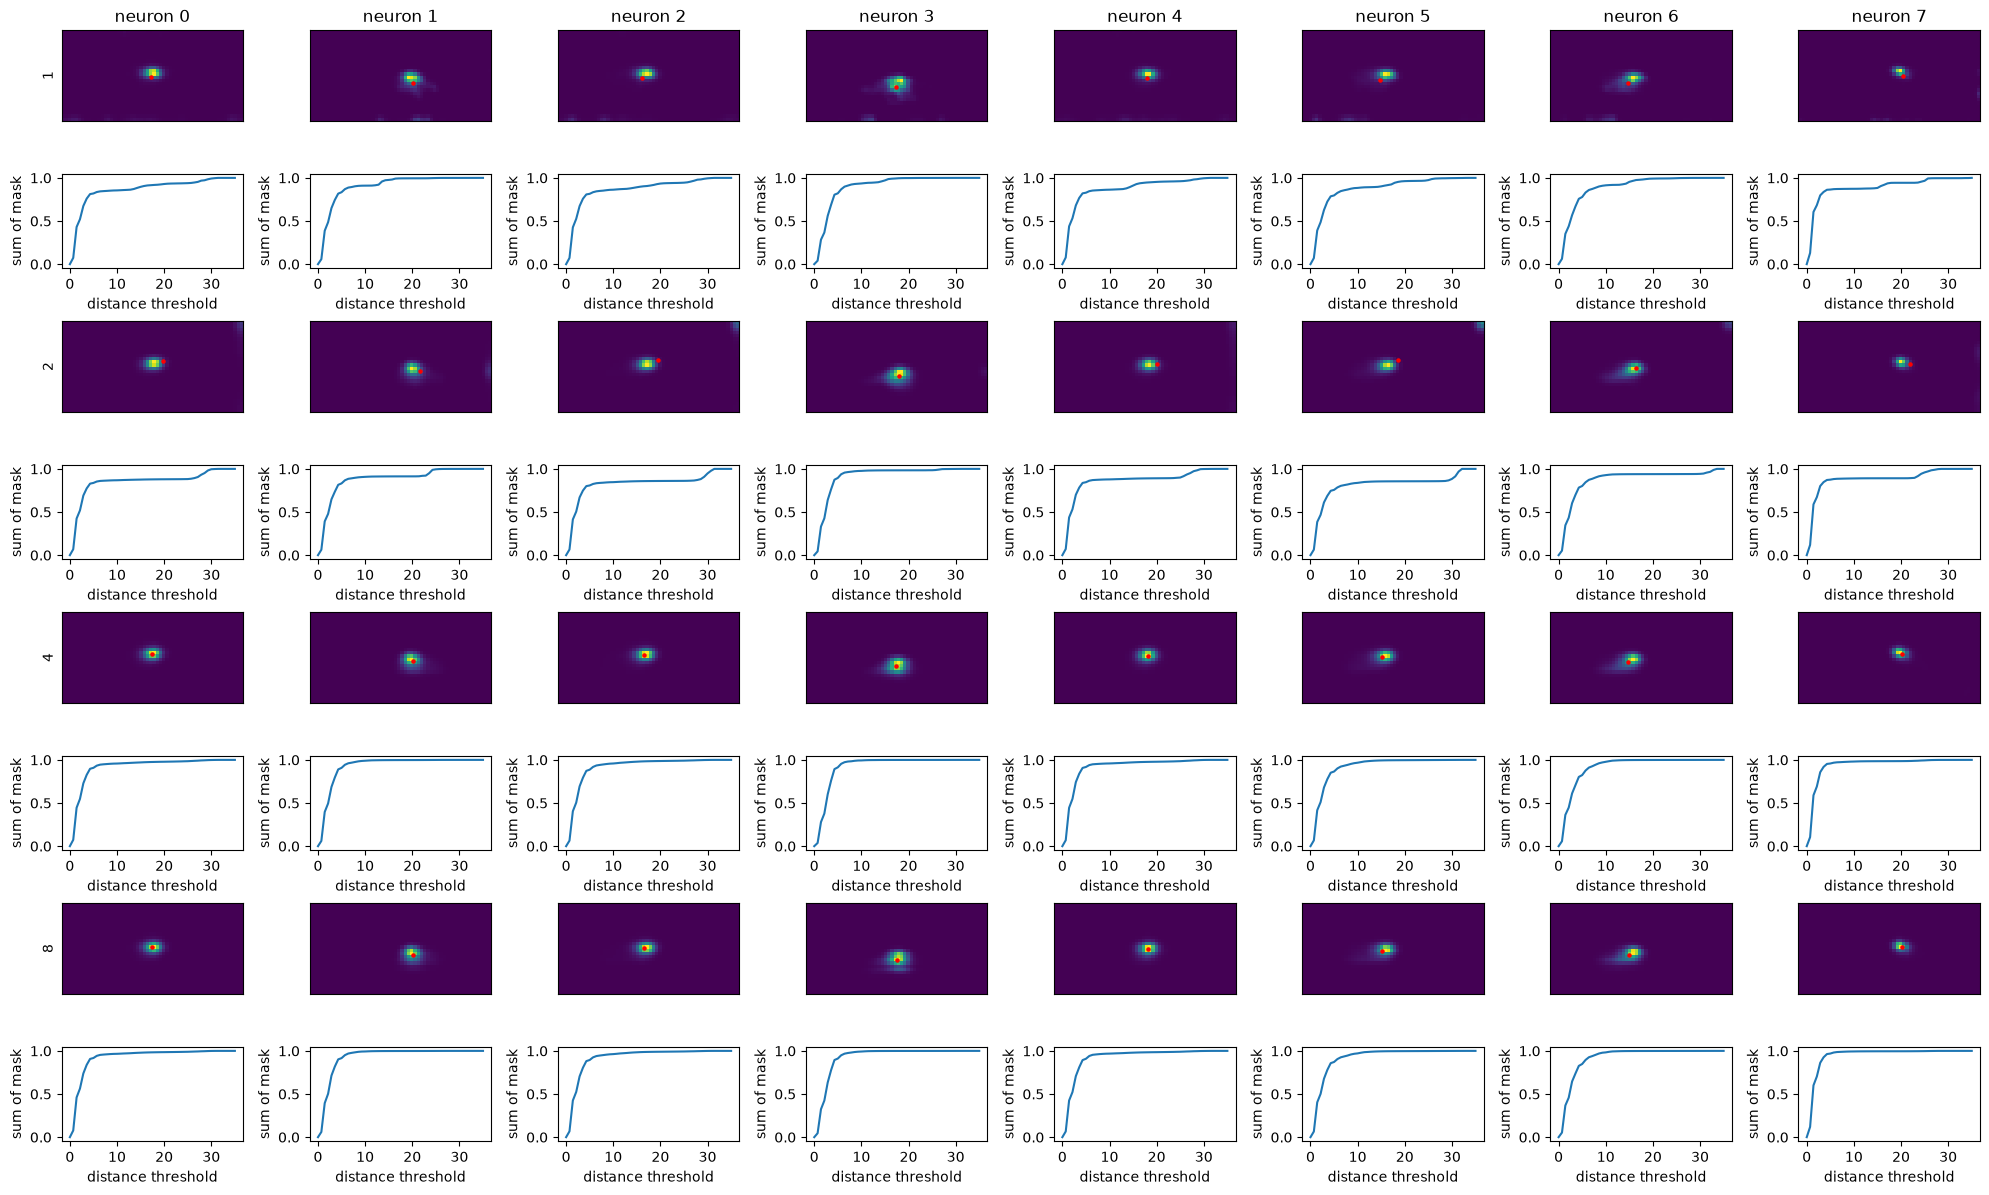

In [78]:
n = 8
fig, axs = plt.subplots(len(models) * 2, n, figsize=(20, 12))
neurons = None

for i, (sigma, sigma_models) in enumerate(models.items()):    
    model = sigma_models[0]
    spatials = torch.cat([model.readout[k].spatial.detach().cpu() for k in [data_keys[6]]])
    neurons = torch.randperm(spatials.shape[0])[:n] if neurons is None else neurons
    for j in range(n):
        ax = axs[i * 2][j]
        spatial = spatials[neurons[j]]

        h, w = spatial.shape
        y = spatial.sum(dim=1)  # h
        x = spatial.sum(dim=0)  # w

        y_pos = torch.arange(h)
        x_pos = torch.arange(w)

        y_avg = (y_pos * y).sum()
        x_avg = (x_pos * x).sum()

        ax.imshow(spatial)
        ax.scatter(x_avg, y_avg, s=5, color='red')
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0:
            ax.set_title(f'neuron {j}')
        if j == 0:
            ax.set_ylabel(sigma)

        y_max = y.argmax()
        x_max = x.argmax()

        y_dist = (y_pos - y_max).pow(2)
        x_dist = (x_pos - x_max).pow(2)

        yy, xx = torch.meshgrid(y_dist, x_dist, indexing='ij')
        dists = torch.stack([xx, yy], dim=-1).sum(-1).sqrt()

        thresholds = torch.linspace(0, 35, steps=50)
        volumes = []
        for t in thresholds:
            vol = spatial[dists < t].sum()
            volumes.append(vol)
        
        ax = axs[i * 2 + 1][j]
        ax.plot(thresholds, volumes)
        ax.set_xlabel('distance threshold')
        ax.set_ylabel('sum of mask')

plt.tight_layout()

In [36]:
full_grids = {}
for sigma, sigma_models in models.items():
    sigma_grids = []
    for model in sigma_models:
        grids = []
        for key in data_keys:
            spatial = model.readout[key].spatial.detach().cpu()
            n, h, w = spatial.shape
            y = spatial.sum(dim=2)  # n, h
            x = spatial.sum(dim=1)  # n, w

            y_pos = torch.arange(h).unsqueeze(0).expand(n, h)
            x_pos = torch.arange(w).unsqueeze(0).expand(n, w)

            y_avg = (y_pos * y).sum(dim=1)
            x_avg = (x_pos * x).sum(dim=1)
            
            grid = torch.stack([x_avg, y_avg], dim=1)
            grids.append(grid)
        sigma_grids.append(grids)

    full_grids[sigma] = sigma_grids

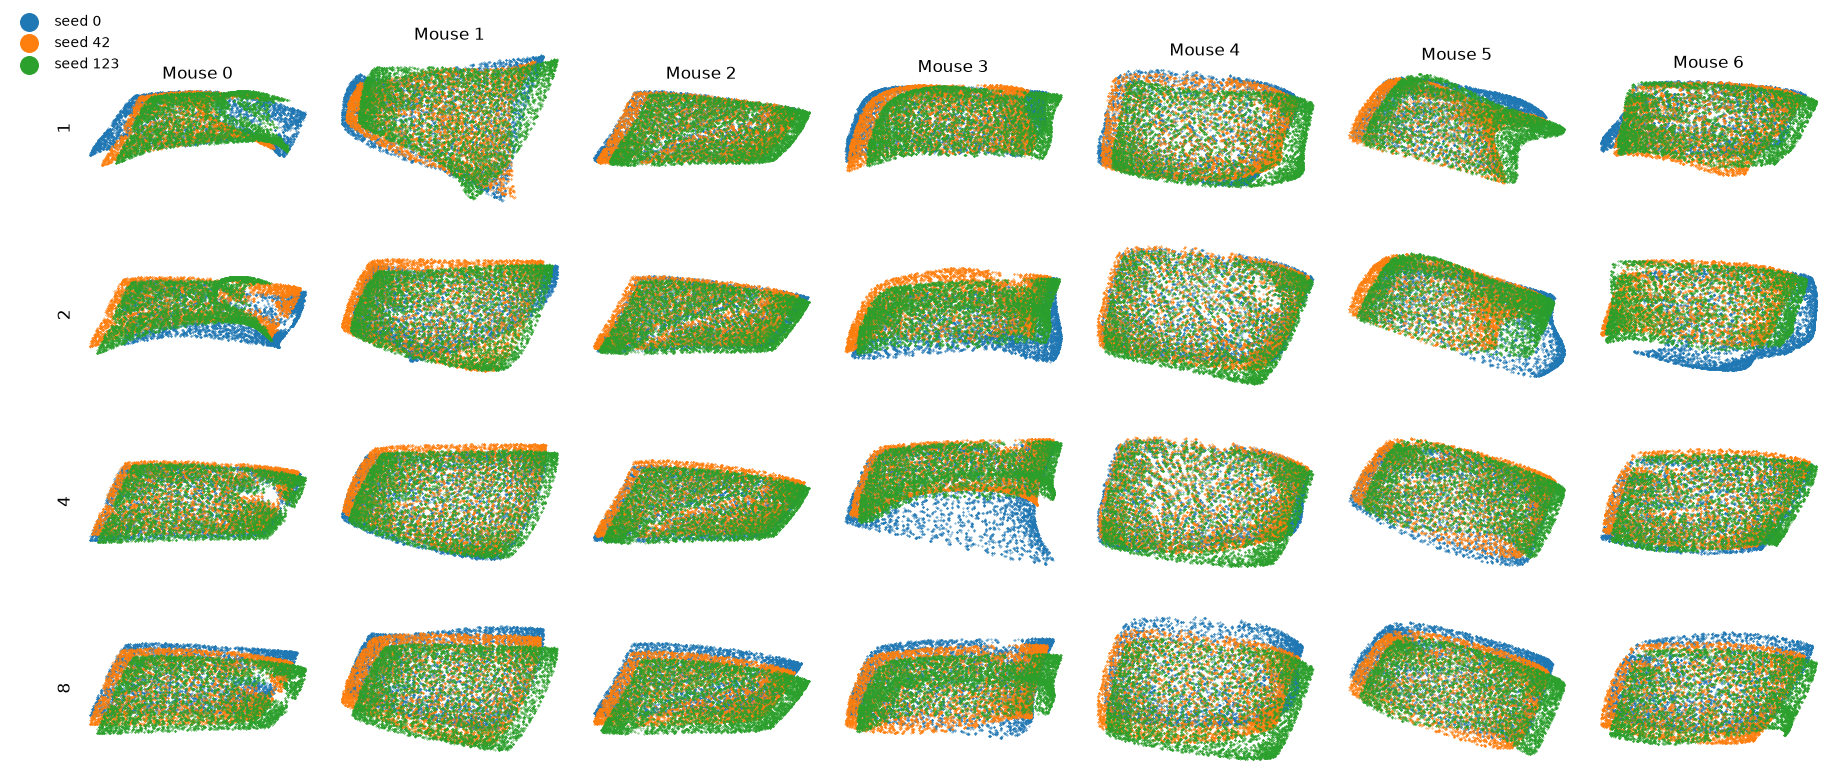

In [38]:
model_seeds = [0, 42, 123]
model_types = full_grids

num_mice = 7
num_models = len(model_seeds)

fig, axs = plt.subplots(len(model_types), num_mice, figsize=(18, 8))

for row_idx, (type_name, grids) in enumerate(full_grids.items()):
    for mouse_idx in range(num_mice):
        ax = axs[row_idx, mouse_idx]
        for model_idx in range(num_models):
            grid = grids[model_idx][mouse_idx]
            ax.scatter(
                grid[:, 0], grid[:, 1],
                alpha=1, s=0.1,
                label=f"seed {model_seeds[model_idx]}",
            )
        ax.set_aspect('equal')

        # remove spines and ticks
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])

        # column labels on top row only
        if row_idx == 0:
            ax.set_title(f"Mouse {mouse_idx}")

        # row labels on first column only
        if mouse_idx == 0:
            ax.set_ylabel(type_name, rotation=90, size='large')

# single shared legend for seeds (bigger markers than the tiny scatter points)
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    bbox_to_anchor=(0.05, 1.0),
    markerscale=40,
    frameon=False,
)

plt.tight_layout()
plt.show()

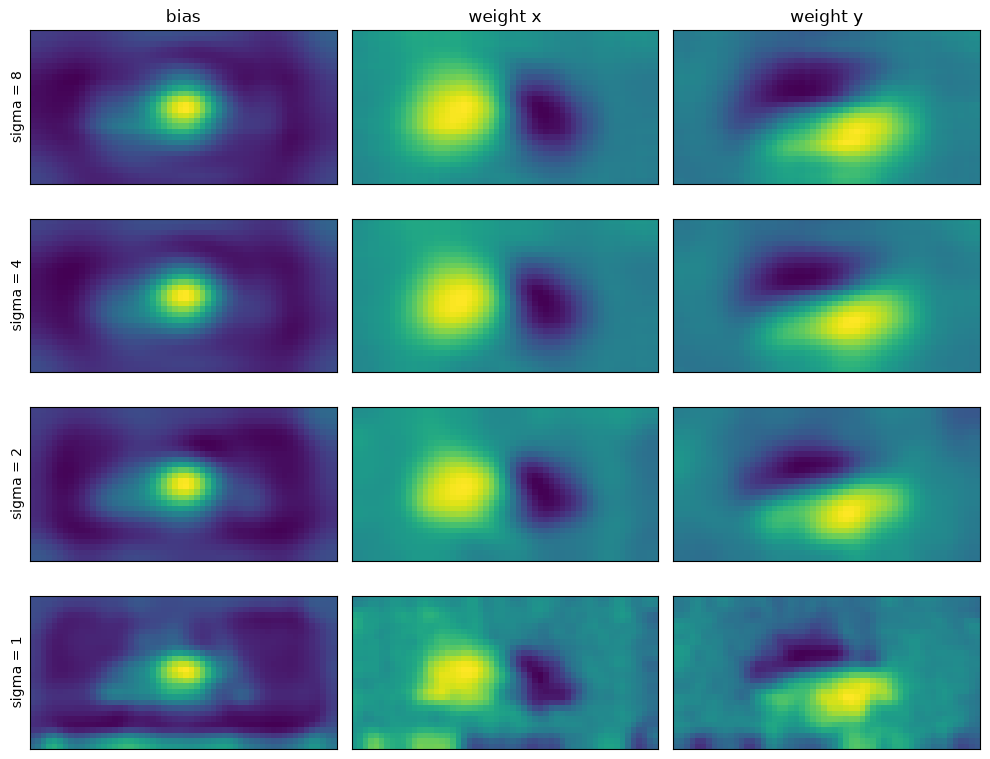

In [64]:
fig, axs = plt.subplots(4, 3, figsize=(10, 8))
for i, (sigma, model) in enumerate(models.items()):
    readout = model.readout[data_keys[6]].to('cpu')
    kernel = readout.gaussian_kernel('cpu')
    bias = readout.smooth(readout.spatial_b, kernel).detach()
    weight = readout.smooth(readout.spatial_w, kernel).detach()
    
    axs[i][0].imshow(bias[0])
    axs[i][0].set_xticks([])
    axs[i][0].set_yticks([])
    axs[i][0].set_ylabel(f'sigma = {sigma}')

    axs[i][1].imshow(weight[1])
    axs[i][1].set_xticks([])
    axs[i][1].set_yticks([])
    
    axs[i][2].imshow(weight[0])
    axs[i][2].set_xticks([])
    axs[i][2].set_yticks([])

    if i == 0:
        axs[i][0].set_title(f'bias')
        axs[i][1].set_title(f'weight x')
        axs[i][2].set_title(f'weight y')

plt.tight_layout()
plt.show()

# knn

In [2]:
paths = {}
for sigma in [1, 2, 4, 8]:
    paths[sigma] = [
        f'../training/runs/sigma{sigma}/sigma{sigma}_seed0',
        f'../training/runs/sigma{sigma}/sigma{sigma}_seed42',
        f'../training/runs/sigma{sigma}/sigma{sigma}_seed123',
    ]

models = {}
for sigma, sigma_paths in paths.items():
    sigma_models = []
    for path in sigma_paths:
        model = load_model_from_config(path, dataloaders, device)
        sigma_models.append(model)
    models[sigma] = sigma_models

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
P

In [3]:
curves = {}
for sigma, sigma_models in models.items():
    readouts = []
    for model in sigma_models:
        r = torch.cat([model.readout[key].features.detach() for key in data_keys])
        r = model.whitener.transform_weights(r.T).T.cpu()
        readouts.append(r)

    curve, k_range = get_knn_curve(readouts)
    curves[sigma] = curve

In [ ]:
curves[1][0]

(array([0.91341849, 0.90541944, 0.86952706, 0.82829995, 0.791756  ,
        0.76283543, 0.72274933, 0.6900438 , 0.67276554, 0.66003083,
        0.65151792, 0.64713914, 0.64456109, 0.64418926, 0.64529312,
        0.64788052, 0.65188648]),
 array([0.00037121, 0.00025199, 0.00052538, 0.00039296, 0.00084663,
        0.00094377, 0.00138599, 0.00160772, 0.00211071, 0.00281465,
        0.00324011, 0.00389086, 0.00392998, 0.00446893, 0.00483884,
        0.00544744, 0.00610113]),
 array([[0.91311917, 0.91383386, 0.91330242],
        [0.90566989, 0.90516594, 0.90542249],
        [0.86997502, 0.86965738, 0.86894879],
        [0.8287535 , 0.82806172, 0.82808463],
        [0.79254155, 0.79186718, 0.79085928],
        [0.76304923, 0.76365397, 0.7618031 ],
        [0.72309828, 0.7239275 , 0.72122221],
        [0.68995717, 0.69169309, 0.68848114],
        [0.67264381, 0.67493449, 0.67071833],
        [0.65961545, 0.66303009, 0.65744694],
        [0.65073895, 0.6550765 , 0.64873829],
        [0.6463079

In [ ]:
for sigma, curve in curves.items():
    m, s = curve[0], curve[1]
    m[-1]

(17,)
(17,)
(17,)
(17,)


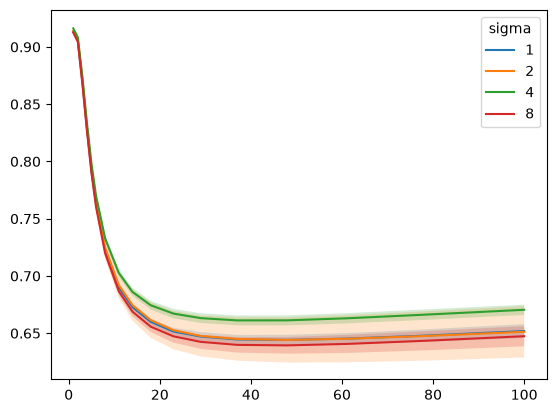

In [90]:
for sigma, curve in curves.items():
    m, s = curve[0], curve[1]
    plt.plot(k_range, m, label=sigma)
    plt.fill_between(k_range, m - s, m + s, alpha=0.2)

plt.legend(title='sigma')
plt.show()

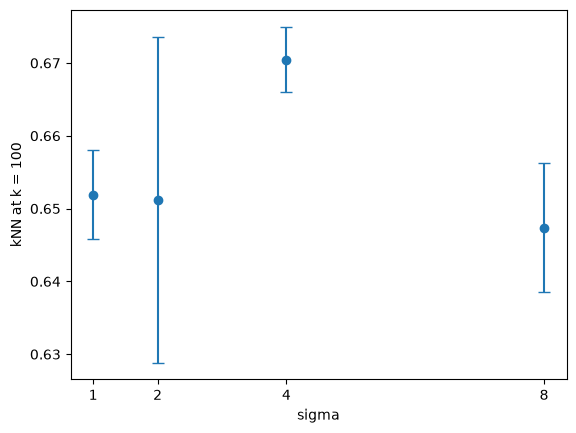

In [91]:
sigmas = sorted(curves.keys())
finals = [curves[s][0][-1] for s in sigmas]  # final mean
stds = [curves[s][1][-1] for s in sigmas]    # final std

plt.errorbar(sigmas, finals, yerr=stds, fmt='o', capsize=4)
plt.xticks(sigmas)
plt.xlabel('sigma')
plt.ylabel('kNN at k = 100')
plt.show()

In [39]:
def gaussian_kernel(size, sigma):
    x = torch.arange(size) - size // 2
    xx, yy = torch.meshgrid(x, x, indexing="ij")
    kernel = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / kernel.sum()
    return kernel.view(1, 1, size, size)

In [ ]:
5: 1
9: 2
17: 4
33: 8

tensor([[4.9322e-05, 6.2838e-05, 7.8817e-05,  ..., 7.8817e-05, 6.2838e-05,
         4.9322e-05],
        [6.2838e-05, 8.0058e-05, 1.0042e-04,  ..., 1.0042e-04, 8.0058e-05,
         6.2838e-05],
        [7.8817e-05, 1.0042e-04, 1.2595e-04,  ..., 1.2595e-04, 1.0042e-04,
         7.8817e-05],
        ...,
        [7.8817e-05, 1.0042e-04, 1.2595e-04,  ..., 1.2595e-04, 1.0042e-04,
         7.8817e-05],
        [6.2838e-05, 8.0058e-05, 1.0042e-04,  ..., 1.0042e-04, 8.0058e-05,
         6.2838e-05],
        [4.9322e-05, 6.2838e-05, 7.8817e-05,  ..., 7.8817e-05, 6.2838e-05,
         4.9322e-05]])


(0.0, 0.0028093391927541235)

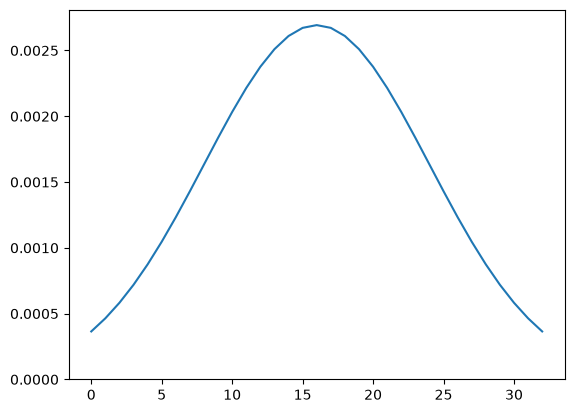

In [95]:
kernel = gaussian_kernel(33, 8)[0, 0]
print(kernel)
plt.plot(kernel[kernel.shape[0] // 2])
plt.ylim(0)
# plt.imshow(kernel, vmin=0)